In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [21]:
df = pd.read_csv('/content/drive/MyDrive/Gold Price Prediction/FINAL_USO.csv')
df.columns = df.columns.str.strip()
# Check dataset shape
print(f"Dataset shape: {df.shape}")
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
df.head()

Dataset shape: (1718, 81)
Duplicate rows: 0


,Date,Open,High,Low,Close,Adj Close,Volume,SP_open,SP_high,SP_low,...,GDX_Low,GDX_Close,GDX_Adj Close,GDX_Volume,USO_Open,USO_High,USO_Low,USO_Close,USO_Adj Close,USO_Volume
0,2011-12-15,154.740005,154.949997,151.710007,152.330002,152.330002,21521900,123.029999,123.199997,121.989998,...,51.570000,51.680000,48.973877,20605600,36.900002,36.939999,36.049999,36.130001,36.130001,12616700
1,2011-12-16,154.309998,155.369995,153.899994,155.229996,155.229996,18124300,122.230003,122.949997,121.300003,...,52.040001,52.680000,49.921513,16285400,36.180000,36.500000,35.730000,36.270000,36.270000,12578800
2,2011-12-19,155.479996,155.860001,154.360001,154.869995,154.869995,12547200,122.059998,122.320000,120.029999,...,51.029999,51.169998,48.490578,15120200,36.389999,36.450001,35.930000,36.200001,36.200001,7418200
3,2011-12-20,156.820007,157.429993,156.580002,156.979996,156.979996,9136300,122.180000,124.139999,120.370003,...,52.369999,52.990002,50.215282,11644900,37.299999,37.610001,37.220001,37.560001,37.560001,10041600
4,2011-12-21,156.979996,157.529999,156.130005,157.160004,157.160004,11996100,123.930000,124.360001,122.750000,...,52.419998,52.959999,50.186852,8724300,37.669998,38.240002,37.520000,38.110001,38.110001,10728000


In [22]:
df['Date'] = pd.to_datetime(df['Date'])
# Handle missing values
if df.isnull().sum().sum() > 0:
    print("Missing values found:")
    print(df.isnull().sum()[df.isnull().sum() > 0])
    df = df.dropna().reset_index(drop=True)
else:
    print("No missing values")
print(f"Final dataset: {len(df)} rows, {len(df.columns)} columns")


No missing values
Final dataset: 1718 rows, 81 columns


In [23]:
TARGET = 'USO_Close'
#features and target
X = df.drop(columns=['Date', TARGET])
y = df[TARGET]
# Remove data leakage
leakage_columns = ['USO_Open', 'USO_High', 'USO_Low', 'USO_Adj Close']
X = X.drop(columns=leakage_columns)
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Features: 75
Samples: 1718

Training samples: 1374
Testing samples: 344


In [24]:
model = RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [25]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2, mae, rmse

(0.9990019253275128, 0.22293234745155466, np.float64(0.3650728952135115))

In [26]:
importance_df = pd.DataFrame({'Feature': X.columns,'Importance': model.feature_importances_}).sort_values(by='Importance', ascending=False)
importance_df

,Feature,Importance
64,USDI_High,0.572721
62,USDI_Price,0.133078
65,USDI_Low,0.126909
63,USDI_Open,0.071230
37,OS_High,0.022823
...,...,...
50,USB_Trend,0.000002
55,PLT_Trend,0.000001
60,PLD_Trend,0.000001
67,USDI_Trend,0.000001


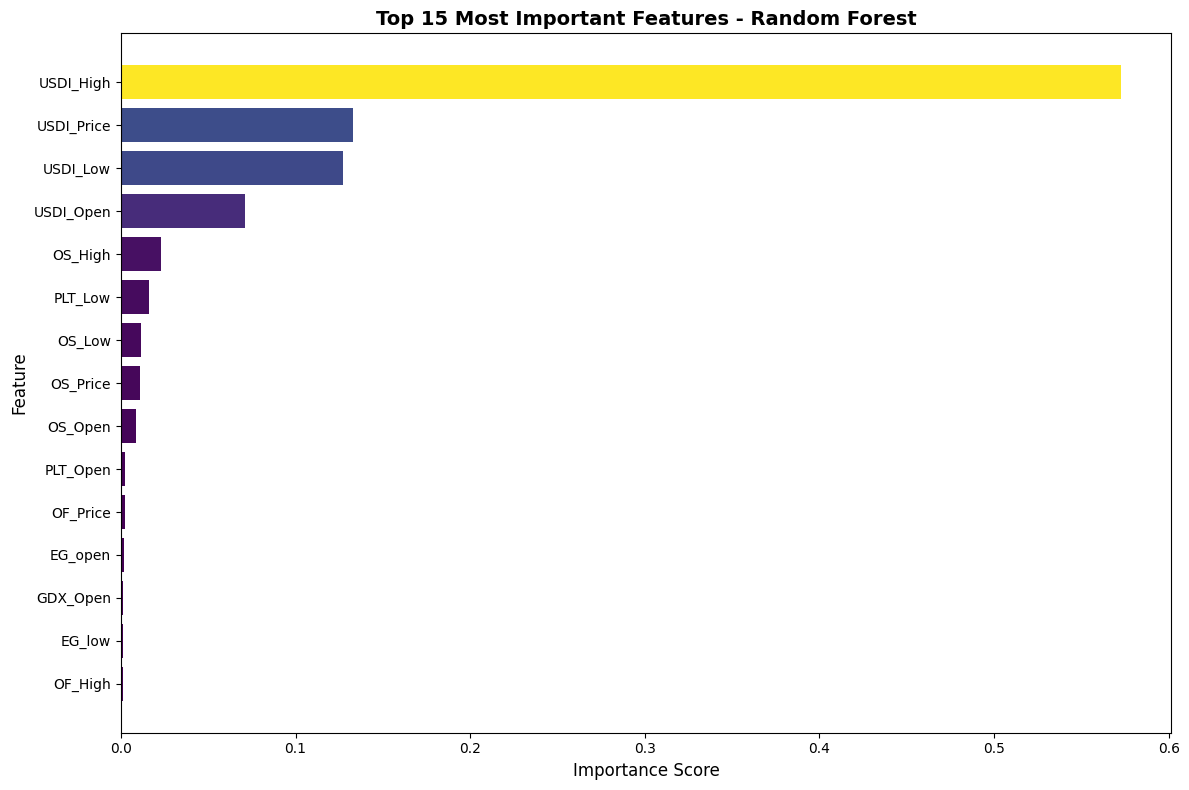

In [27]:
top_k = 15
top_features = importance_df.head(top_k)
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(top_features['Importance'] / top_features['Importance'].max())
plt.barh(top_features['Feature'], top_features['Importance'], color=colors)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_k} Most Important Features - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [34]:
sample_df = X.iloc[[0]]
prediction = model.predict(sample_df)
print(f"\nSample prediction:")
print(f"Predicted USO_Close: ${prediction[0]:.2f}")
print(f"Model RMSE: ${rmse:.4f}")
print(f"Expected range: ${prediction[0] - 2*rmse:.2f} - ${prediction[0] + 2*rmse:.2f}")


Sample prediction:
Predicted USO_Close: $36.01
Model RMSE: $0.3651
Expected range: $35.28 - $36.74


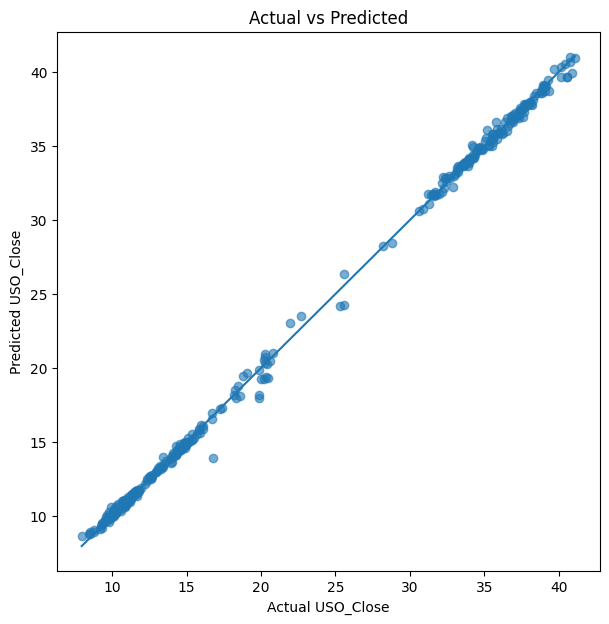

In [29]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()])
plt.xlabel('Actual USO_Close')
plt.ylabel('Predicted USO_Close')
plt.title('Actual vs Predicted')
plt.show()

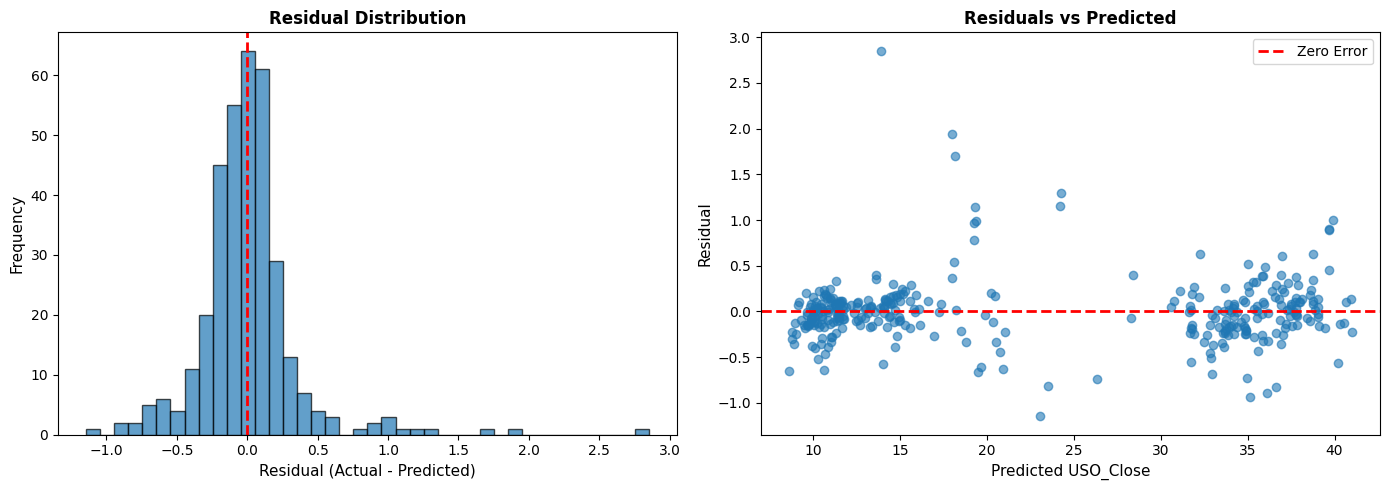

In [30]:
# Residual Analysis
residuals = y_test.values - y_pred
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Histogram
ax1.hist(residuals, bins=40, edgecolor='black', alpha=0.7)
ax1.axvline(0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Residual (Actual - Predicted)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Residual Distribution', fontsize=12, fontweight='bold')
# Scatter plot
ax2.scatter(y_pred, residuals, alpha=0.6)
ax2.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax2.set_xlabel('Predicted USO_Close', fontsize=11)
ax2.set_ylabel('Residual', fontsize=11)
ax2.set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')
ax2.legend()
plt.tight_layout()
plt.show()

In [33]:
print("Performance Summary")
eval_summary = pd.DataFrame({
    'Metric': ['R² Score', 'MAE ($)', 'RMSE ($)'],
    'Value': [r2, mae, rmse]
})
print(eval_summary.to_string(index=False))


Performance Summary
  Metric    Value
R² Score 0.999002
 MAE ($) 0.222932
RMSE ($) 0.365073
